IMPORTS ET CHARGEMENTS

In [4]:
import sys
sys.path.append("..")  

import pandas as pd
import numpy as np
from src.db import get_engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

engine = get_engine()

TABLES = [
    "customers", "orders", "order_items", "order_payments", "order_reviews",
    "products", "sellers", "geolocation", "category_translation",
]
dfs = {t: pd.read_sql(f"SELECT * FROM raw.{t}", engine) for t in TABLES}

issues = []
def log_issue(table, check, n_affected, comment):
    issues.append({"table": table, "check": check,
                   "n_affected": int(n_affected), "comment": comment})

TYPES ET VALEURS MANQUANTES DE TOUTES LES TABLES

In [5]:
def profile(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_null": df.isna().sum(),
        "pct_null": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    })

for name, df in dfs.items():
    print(f"\n=== {name} : {df.shape[0]:,} lignes x {df.shape[1]} colonnes ===")
    p = profile(df)
    display(p[p["n_null"] > 0] if p["n_null"].any() else p.head(0))
    for col, row in p[p["n_null"] > 0].iterrows():
        log_issue(name, f"valeurs manquantes : {col}", row["n_null"],
                  f"{row['pct_null']}% de la colonne")


=== customers : 99,441 lignes x 5 colonnes ===


,dtype,n_null,pct_null,n_unique



=== orders : 99,441 lignes x 8 colonnes ===


,dtype,n_null,pct_null,n_unique
order_approved_at,datetime64[us],160,0.16,90733
order_delivered_carrier_date,datetime64[us],1783,1.79,81018
order_delivered_customer_date,datetime64[us],2965,2.98,95664



=== order_items : 112,650 lignes x 7 colonnes ===


...

,dtype,n_null,pct_null,n_unique



=== geolocation : 1,000,163 lignes x 5 colonnes ===


,dtype,n_null,pct_null,n_unique



=== category_translation : 71 lignes x 2 colonnes ===


,dtype,n_null,pct_null,n_unique


DOUBLONS

In [6]:
for name, df in dfs.items():
    n_dup = df.duplicated().sum()
    print(f"{name:22s} lignes entièrement dupliquées : {n_dup:,}")
    if n_dup:
        log_issue(name, "lignes entièrement dupliquées", n_dup,
                  "à dédoublonner ou à justifier")

keys = {
    "orders": ["order_id"],
    "customers": ["customer_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "category_translation": ["product_category_name"],
}
for name, k in keys.items():
    n = dfs[name].duplicated(subset=k).sum()
    print(f"{name:22s} doublons sur clé {k} : {n:,}")
    if n:
        log_issue(name, f"clé non unique {k}", n, "")

customers              lignes entièrement dupliquées : 0
orders                 lignes entièrement dupliquées : 0
order_items            lignes entièrement dupliquées : 0
order_payments         lignes entièrement dupliquées : 0
order_reviews          lignes entièrement dupliquées : 0
products               lignes entièrement dupliquées : 0
sellers                lignes entièrement dupliquées : 0
geolocation            lignes entièrement dupliquées : 261,831
category_translation   lignes entièrement dupliquées : 0
orders                 doublons sur clé ['order_id'] : 0
customers              doublons sur clé ['customer_id'] : 0
products               doublons sur clé ['product_id'] : 0
sellers                doublons sur clé ['seller_id'] : 0
order_items            doublons sur clé ['order_id', 'order_item_id'] : 0
order_payments         doublons sur clé ['order_id', 'payment_sequential'] : 0
order_reviews          doublons sur clé ['review_id'] : 814
category_translation   doublons su

IDENTIFIANTS ET INTÉGRITÉ RÉFÉRENTIELLES

In [7]:
o, c, it, pay, prod, sel = (dfs[k] for k in
    ["orders", "customers", "order_items", "order_payments", "products", "sellers"])

n_cid = c["customer_id"].nunique()
n_uid = c["customer_unique_id"].nunique()
print(f"customer_id distincts        : {n_cid:,}")
print(f"customer_unique_id distincts : {n_uid:,}")
log_issue("customers", "customer_id est par commande", n_cid - n_uid,
          "utiliser customer_unique_id pour compter les clients")

orders_per_client = (o.merge(c[["customer_id", "customer_unique_id"]], on="customer_id")
                       .groupby("customer_unique_id")["order_id"].nunique())
print(f"\nClients avec >1 commande : {(orders_per_client > 1).mean():.2%}")
print(orders_per_client.value_counts().sort_index().head(8))

checks = {
    "orders sans client":            ~o["customer_id"].isin(c["customer_id"]),
    "orders sans ligne d'items":     ~o["order_id"].isin(it["order_id"]),
    "orders sans paiement":          ~o["order_id"].isin(pay["order_id"]),
}
for label, mask in checks.items():
    print(f"{label:35s} {mask.sum():,}")
    if mask.sum():
        log_issue("orders", label, mask.sum(), "")

orph = {
    "items avec order_id inconnu":   (~it["order_id"].isin(o["order_id"])).sum(),
    "items avec product_id inconnu": (~it["product_id"].isin(prod["product_id"])).sum(),
    "items avec seller_id inconnu":  (~it["seller_id"].isin(sel["seller_id"])).sum(),
    "paiements avec order_id inconnu": (~pay["order_id"].isin(o["order_id"])).sum(),
}
for label, n in orph.items():
    print(f"{label:35s} {n:,}")
    if n:
        log_issue("order_items/payments", label, n, "")

customer_id distincts        : 99,441
customer_unique_id distincts : 96,096

Clients avec >1 commande : 3.12%
order_id
1    93099
2     2745
3      203
4       30
5        8
6        6
7        3
9        1
Name: count, dtype: int64
orders sans client                  0
orders sans ligne d'items           775
orders sans paiement                1
items avec order_id inconnu         0
items avec product_id inconnu       0
items avec seller_id inconnu        0
paiements avec order_id inconnu     0


STATUT ET CATÉGORIE

In [8]:
print(o["order_status"].value_counts(dropna=False))
print((o["order_status"].value_counts(normalize=True) * 100).round(2))

print("\nMoyens de paiement :")
print(pay["payment_type"].value_counts(dropna=False))

tr = dfs["category_translation"]
null_cat = prod["product_category_name"].isna().sum()
no_tr = (~prod["product_category_name"].dropna().isin(tr["product_category_name"])).sum()
print(f"\nProduits sans catégorie         : {null_cat:,}")
print(f"Produits avec catégorie non traduite : {no_tr:,}")
print(prod.loc[~prod["product_category_name"].isin(tr["product_category_name"])
               & prod["product_category_name"].notna(),
               "product_category_name"].value_counts())

for df_name, col in [("products", "product_category_name"),
                     ("customers", "customer_city"),
                     ("customers", "customer_state")]:
    s = dfs[df_name][col].dropna()
    n_bad = (s != s.str.strip()).sum()
    print(f"{df_name}.{col} : valeurs avec espaces parasites = {n_bad:,}")
print("États distincts :", sorted(c["customer_state"].unique()))

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
order_status
delivered     97.02
shipped        1.11
canceled       0.63
unavailable    0.61
invoiced       0.32
processing     0.30
created        0.01
approved       0.00
Name: proportion, dtype: float64

Moyens de paiement :
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Produits sans catégorie         : 610
Produits avec catégorie non traduite : 13
product_category_name
portateis_cozinha_e_preparadores_de_alimentos    10
pc_gamer                                          3
Name: count, dtype: int64
products.product_category_name : valeurs avec espaces parasites = 0
customers.customer_city : valeurs avec espaces parasites = 0
customers.customer_state : valeurs avec espaces parasites =

DATES

                                              min                 max
order_purchase_timestamp      2016-09-04 21:15:19 2018-10-17 17:30:18
order_approved_at             2016-09-15 12:16:38 2018-09-03 17:40:06
order_delivered_carrier_date  2016-10-08 10:34:01 2018-09-11 19:48:28
order_delivered_customer_date 2016-10-11 13:46:32 2018-10-17 13:22:46
order_estimated_delivery_date 2016-09-30 00:00:00 2018-11-12 00:00:00
order_purchase_timestamp
2016-09-01       4
2016-10-01     324
2016-11-01       0
2016-12-01       1
2017-01-01     800
2017-02-01    1780
2017-03-01    2682
2017-04-01    2404
2017-05-01    3700
2017-06-01    3245
2017-07-01    4026
2017-08-01    4331
2017-09-01    4285
2017-10-01    4631
2017-11-01    7544
2017-12-01    5673
2018-01-01    7269
2018-02-01    6728
2018-03-01    7211
2018-04-01    6939
2018-05-01    6873
2018-06-01    6167
2018-07-01    6292
2018-08-01    6512
2018-09-01      16
2018-10-01       4
Freq: MS, Name: order_id, dtype: int64
approbation avant acha

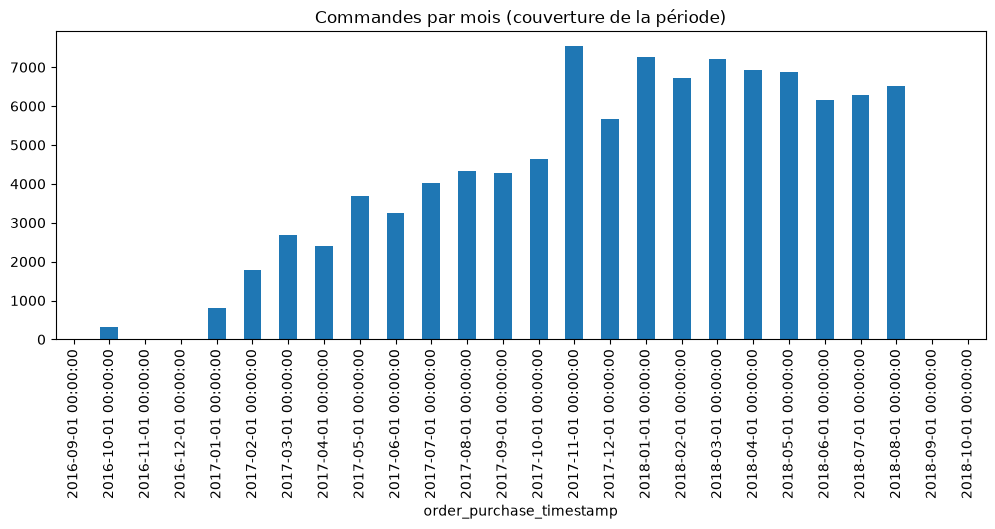

In [9]:
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
print(o[date_cols].agg(["min", "max"]).T)

monthly = (o.set_index("order_purchase_timestamp")
             .resample("MS")["order_id"].count())
print(monthly)
monthly.plot(kind="bar", figsize=(12, 4),
             title="Commandes par mois (couverture de la période)")


chrono = {
    "approbation avant achat":     o["order_approved_at"] < o["order_purchase_timestamp"],
    "transporteur avant approbation": o["order_delivered_carrier_date"] < o["order_approved_at"],
    "livraison avant achat":       o["order_delivered_customer_date"] < o["order_purchase_timestamp"],
    "livraison avant transporteur": o["order_delivered_customer_date"] < o["order_delivered_carrier_date"],
}
for label, mask in chrono.items():
    print(f"{label:35s} {mask.sum():,}")
    if mask.sum():
        log_issue("orders", f"incohérence chronologique : {label}", mask.sum(), "")


delivered_no_date = ((o["order_status"] == "delivered")
                     & o["order_delivered_customer_date"].isna()).sum()
not_delivered_with_date = ((o["order_status"] != "delivered")
                           & o["order_delivered_customer_date"].notna()).sum()
print(f"\nStatut 'delivered' sans date de livraison : {delivered_no_date:,}")
print(f"Statut autre que 'delivered' avec date de livraison : {not_delivered_with_date:,}")
for label, n in [("delivered sans date de livraison", delivered_no_date),
                 ("non delivered avec date de livraison", not_delivered_with_date)]:
    if n:
        log_issue("orders", label, n, "incohérence statut/date")

VALEURS NÉGATIVES ET ABERRANTES

In [10]:
#Val impossibles
neg = {
    "items.price <= 0":          (it["price"] <= 0).sum(),
    "items.freight_value < 0":   (it["freight_value"] < 0).sum(),
    "payments.payment_value < 0": (pay["payment_value"] < 0).sum(),
    "payments.payment_value = 0": (pay["payment_value"] == 0).sum(),
    "products.weight_g = 0":      (prod["product_weight_g"] == 0).sum(),
    "reviews.score hors 1-5":     (~dfs["order_reviews"]["review_score"].between(1, 5)).sum(),
    "payments.installments = 0":  (pay["payment_installments"] == 0).sum(),
}
for label, n in neg.items():
    print(f"{label:30s} {n:,}")
    if n:
        log_issue("valeurs impossibles/suspectes", label, n, "")

# Vals aberrantes (méthode IQR) : REPÈRE SANS SUPPRESSION
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

for df_name, col in [("order_items", "price"), ("order_items", "freight_value"),
                     ("products", "product_weight_g")]:
    s = dfs[df_name][col].dropna()
    mask = iqr_outliers(s)
    print(f"\n{df_name}.{col} : {mask.sum():,} outliers IQR ({mask.mean():.2%})")
    print(s.describe(percentiles=[.5, .95, .99, .999]))
    log_issue(df_name, f"outliers IQR : {col}", mask.sum(),
              "valeurs extrêmes à examiner, pas forcément des erreurs")

# Les plus grosses lignes : erreurs de saisie ou produits réellement chers ?
print(it.nlargest(10, "price")[["order_id", "product_id", "price", "freight_value"]])

items.price <= 0               0
items.freight_value < 0        0
payments.payment_value < 0     0
payments.payment_value = 0     9
products.weight_g = 0          4
reviews.score hors 1-5         0
payments.installments = 0      2

order_items.price : 8,427 outliers IQR (7.48%)
count   112,650.00
mean        120.65
std         183.63
min           0.85
50%          74.99
95%         349.90
99%         890.00
99.9%     2,110.00
max       6,735.00
Name: price, dtype: float64

order_items.freight_value : 12,134 outliers IQR (10.77%)
count   112,650.00
mean         19.99
std          15.81
min           0.00
50%          16.26
95%          45.12
99%          84.52
99.9%       175.59
max         409.68
Name: freight_value, dtype: float64

products.product_weight_g : 4,551 outliers IQR (13.81%)
count   32,949.00
mean     2,276.47
std      4,282.04
min          0.00
50%        700.00
95%     10,850.00
99%     22,538.00
99.9%   30,000.00
max     40,425.00
Name: product_weight_g, dtype: float64

COHÉRENCE DES MONTANTS 

In [11]:
# Total items (price + freight) vs total paiements, par commande
items_total = (it.groupby("order_id")
                 .apply(lambda g: (g["price"] + g["freight_value"]).sum(),
                        include_groups=False)
                 .rename("items_total"))
pay_total = pay.groupby("order_id")["payment_value"].sum().rename("payment_total")

recon = pd.concat([items_total, pay_total], axis=1).dropna()
recon["diff"] = (recon["payment_total"] - recon["items_total"]).round(2)

n_mismatch = (recon["diff"].abs() > 0.01).sum()
print(f"Commandes comparables : {len(recon):,}")
print(f"Écart items vs paiements > 0.01 BRL : {n_mismatch:,} ({n_mismatch/len(recon):.2%})")
print(recon["diff"].describe())
log_issue("items vs payments", "écart total items vs total paiements",
          n_mismatch, "à comprendre avant de choisir la définition du CA")

# Risque de doublonnage du CA : combien de commandes ont plusieurs paiements ?
multi_pay = (pay.groupby("order_id").size() > 1).sum()
print(f"Commandes avec plusieurs paiements : {multi_pay:,}")
log_issue("order_payments", "commandes avec plusieurs paiements", multi_pay,
          "ne pas joindre items et payments sans agréger")

Commandes comparables : 98,665
Écart items vs paiements > 0.01 BRL : 303 (0.31%)
count   98,665.00
mean         0.03
std          1.13
min        -51.62
25%          0.00
50%          0.00
75%          0.00
max        182.81
Name: diff, dtype: float64
Commandes avec plusieurs paiements : 2,961


In [ ]:
GÉOLOCALISATION ET AVIS

In [12]:
g = dfs["geolocation"]
n_zip = g["geolocation_zip_code_prefix"].nunique()
print(f"Lignes : {len(g):,} | codes postaux distincts : {n_zip:,}")
print(f"Moyenne de lignes par code postal : {len(g)/n_zip:.1f}")
log_issue("geolocation", "plusieurs coordonnées par code postal",
          len(g) - n_zip, "agréger (médiane lat/lng) avant toute jointure")

# Coordonnées hors du Brésil (approx. : lat -34 à 6, lng -74 à -34)
out = ~(g["geolocation_lat"].between(-34, 6) & g["geolocation_lng"].between(-74, -34))
print(f"Coordonnées hors Brésil : {out.sum():,}")
if out.sum():
    log_issue("geolocation", "coordonnées hors du Brésil", out.sum(), "")

# Avis : review_id répétés
r = dfs["order_reviews"]
print(f"review_id répétés : {r['review_id'].duplicated().sum():,}")
print(f"Commandes avec plusieurs avis : {(r.groupby('order_id').size() > 1).sum():,}")

Lignes : 1,000,163 | codes postaux distincts : 19,015
Moyenne de lignes par code postal : 52.6
Coordonnées hors Brésil : 42
review_id répétés : 814
Commandes avec plusieurs avis : 547


BILAN DES CONSTATS

In [13]:
report = pd.DataFrame(issues).sort_values(["table", "n_affected"], ascending=[True, False])
report.to_csv("../reports/data_quality_issues.csv", index=False)
display(report)

,table,check,n_affected,comment
15,customers,customer_id est par commande,3345,utiliser customer_unique_id pour compter les c...
30,geolocation,plusieurs coordonnées par code postal,981148,agréger (médiane lat/lng) avant toute jointure
13,geolocation,lignes entièrement dupliquées,261831,à dédoublonner ou à justifier
31,geolocation,coordonnées hors du Brésil,42,
28,items vs payments,écart total items vs total paiements,303,à comprendre avant de choisir la définition du CA
26,order_items,outliers IQR : freight_value,12134,"valeurs extrêmes à examiner, pas forcément des..."
25,order_items,outliers IQR : price,8427,"valeurs extrêmes à examiner, pas forcément des..."
29,order_payments,commandes avec plusieurs paiements,2961,ne pas joindre items et payments sans agréger
3,order_reviews,valeurs manquantes : review_comment_title,87656,88.34% de la colonne
4,order_reviews,valeurs manquantes : review_comment_message,58247,58.7% de la colonne
